# Atividade 001 - Pipeline de Classificacao: Dataset `planets`

**Disciplina:** Inteligência Artificial  
**Professor:** Marcelo Batista  

## Objetivo
Treinar um modelo de ML no dataset `planets` de forma **reprodutivel** usando:
- **Dados -> Treino -> Teste**
- **Pipeline + ColumnTransformer** (tratando missing values e colunas categoricas)
- **Baseline:** Decision Tree
- **Melhoria simples:** Random Forest
- **Avaliacao:** accuracy, classification_report, matriz de confusao
- **Interpretacao humana** dos erros por classe

---

## Parte 1 - Definicao do problema

| Item | Descricao |
|---|---|
| **Dataset** | `planets` (Seaborn) - dados de exoplanetas descobertos ate 2014 |
| **Target (y)** | `method` - metodo de deteccao do exoplaneta (multiclasse) |
| **Tipo de problema** | Classificacao multiclasse |
| **Features (X)** | `number`, `orbital_period`, `mass`, `distance`, `year` |
| **Colunas removidas** | Nenhuma - todas as features disponiveis sao numericas e fisicamente relevantes |

Justificativa do target: o método de detecção é determinado, em grande parte, pelas propriedades físicas do planeta e pelo contexto da descoberta. Por exemplo, o método **Transit** detecta planetas que cruzam a estrela (órbitas curtas), enquanto **Radial Velocity** tende a pegar planetas mais massivos. Isso torna `method` um target naturalmente ligado as features numéricas disponíveis.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Parte 2 - Diagnóstico dos dados

In [2]:
df = sns.load_dataset("planets")

display(df.head())
print("Shape:", df.shape)

print("\nTipos das colunas:")
print(df.dtypes)

print("\nMissing values por coluna:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDistribuicao do target (method):")
display(df["method"].value_counts())
display(df["method"].value_counts(normalize=True).rename("proporcao").round(4))

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


Shape: (1035, 6)

Tipos das colunas:
method             object
number              int64
orbital_period    float64
mass              float64
distance          float64
year                int64
dtype: object

Missing values por coluna:


,0
mass,522
distance,227
orbital_period,43
method,0
number,0
year,0



Distribuicao do target (method):


,count
method,
Radial Velocity,553
Transit,397
Imaging,38
Microlensing,23
Eclipse Timing Variations,9
Pulsar Timing,5
Transit Timing Variations,4
Orbital Brightness Modulation,3
Astrometry,2


,proporcao
method,
Radial Velocity,0.5343
Transit,0.3836
Imaging,0.0367
Microlensing,0.0222
Eclipse Timing Variations,0.0087
Pulsar Timing,0.0048
Transit Timing Variations,0.0039
Orbital Brightness Modulation,0.0029
Astrometry,0.0019


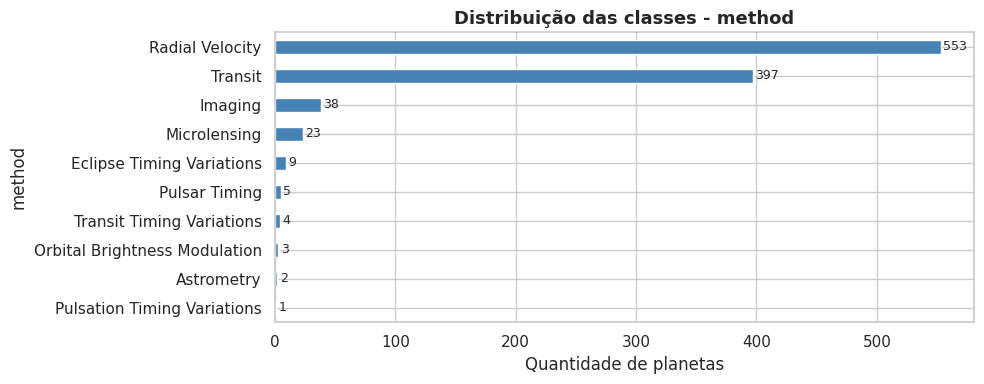

In [3]:
# Visualizar a distribuicao do target
fig, ax = plt.subplots(figsize=(10, 4))
counts = df["method"].value_counts()
counts.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Distribuição das classes - method", fontsize=13, fontweight="bold")
ax.set_xlabel("Quantidade de planetas")
ax.invert_yaxis()
for i, v in enumerate(counts):
    ax.text(v + 2, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

**O que o diagnóstico mostra:**
- Shape: ~1035 linhas x 6 colunas (5 features + 1 target)
- Todas as features são numéricas - não há colunas categóricas entre as features
- `mass` e `distance` possuem missing values relevantes - imputação obrigatória
- O target `method` não tem missing values
- Desbalanceamento forte: `Radial Velocity` e `Transit` somam mais de 90% dos dados; classes como `Astrometry` tem apenas 2 exemplos

## Parte 3 - Construção do Pipeline

Por que precisamos de Pipeline + ColumnTransformer?

No dataset `planets`, temos:
- **Missing values** (NaN em `mass` e `distance`): precisamos imputar de forma consistente
- **Reprodutibilidade**: o pré-processamento deve acontecer **dentro do Pipeline**
  - O pré-processamento aprende no treino
  - E aplica no teste
  - Evita *data leakage*

In [4]:
FEATURES = ["number", "orbital_period", "mass", "distance", "year"]
TARGET = "method"

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Remover classes com menos de 2 exemplos (inviabilizam o stratify)
contagem = y.value_counts()
classes_validas = contagem[contagem >= 2].index
mask = y.isin(classes_validas)
X = X[mask]
y = y[mask]

print("Shape de X:", X.shape)
print("Classes:", sorted(y.unique()))
print("Missing em X:")
print(X.isna().sum())

Shape de X: (1034, 5)
Classes: ['Astrometry', 'Eclipse Timing Variations', 'Imaging', 'Microlensing', 'Orbital Brightness Modulation', 'Pulsar Timing', 'Radial Velocity', 'Transit', 'Transit Timing Variations']
Missing em X:
number              0
orbital_period     43
mass              521
distance          226
year                0
dtype: int64


In [5]:
# Split treino/teste com stratify para manter a proporcao das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train.shape[0], "amostras")
print("Teste: ", X_test.shape[0], "amostras")

print("\nDistribuicao no treino:")
display(y_train.value_counts())

print("Proporcao no teste:")
display(y_test.value_counts(normalize=True).rename("proporcao").round(4))

Treino: 827 amostras
Teste:  207 amostras

Distribuicao no treino:


,count
method,
Radial Velocity,442
Transit,318
Imaging,30
Microlensing,18
Eclipse Timing Variations,7
Pulsar Timing,4
Transit Timing Variations,3
Orbital Brightness Modulation,3
Astrometry,2


Proporcao no teste:


,proporcao
method,
Radial Velocity,0.5362
Transit,0.3816
Imaging,0.0386
Microlensing,0.0242
Eclipse Timing Variations,0.0097
Pulsar Timing,0.0048
Transit Timing Variations,0.0048


In [6]:
# Todas as features sao numericas - um unico pipe numerico basta
# SimpleImputer(median): robusto a outliers, aprende somente no treino
# StandardScaler: padroniza para media=0, desvio=1
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, FEATURES),
    ],
    remainder="drop"
)

preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['number', 'orbital_period', 'mass',
                                  'distance', 'year'])])

## Função de avaliação

In [7]:
def avaliar_classificacao(nome, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))

    print(f"\n=== {nome} ===")
    print(f"Accuracy:    {acc:.4f}")
    print(f"F1-macro:    {f1_macro:.4f}")
    print(f"F1-weighted: {f1_weighted:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Matriz de confusao (linhas=real, colunas=previsto):")
    print(cm)

    # Interpretacao por classe: erro mais comum por metodo
    print("\nInterpretacao por classe (erros fora da diagonal):")
    labels = sorted(y_true.unique())
    for i, label in enumerate(labels):
        fn_row = cm[i].sum() - cm[i][i]   # real=label, previsto=outro
        fp_col = cm[:, i].sum() - cm[i][i]  # real=outro, previsto=label
        if fn_row > 0 or fp_col > 0:
            print(f"- {label}: FN={fn_row} (nao reconhecido) | FP={fp_col} (confundido com este metodo)")

    return {"acc": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted, "cm": cm}

## Parte 4 - Modelos: Baseline + Melhoria

Baseline - Decision Tree:
- Modelo simples e interpretável; cria regras do tipo "se orbital_period < X, então method = Transit"
- Serve como referência mínima: qualquer modelo mais potente deve superar este resultado

Melhoria - Random Forest:
- Ensemble de 100 árvores com bootstrap e amostragem de features
- Reduz overfitting e variância sem exigir hiperparametrização elaborada
- A comparação é justa: o pré-processamento e idêntico nos dois experimentos

In [8]:
# Baseline - Decision Tree
model_baseline_dt = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

print("Treinando baseline (DecisionTreeClassifier)...")
model_baseline_dt.fit(X_train, y_train)

pred_baseline_dt = model_baseline_dt.predict(X_test)

res_dt = avaliar_classificacao("Baseline - DecisionTreeClassifier", y_test, pred_baseline_dt)
acc_baseline_dt = res_dt["acc"]

Treinando baseline (DecisionTreeClassifier)...

=== Baseline - DecisionTreeClassifier ===
Accuracy:    0.9082
F1-macro:    0.4749
F1-weighted: 0.9013

Classification report:
                           precision    recall  f1-score   support

Eclipse Timing Variations       0.00      0.00      0.00         2
                  Imaging       0.64      0.88      0.74         8
             Microlensing       0.67      0.80      0.73         5
            Pulsar Timing       0.00      0.00      0.00         1
          Radial Velocity       0.95      0.93      0.94       111
                  Transit       0.90      0.94      0.92        79
Transit Timing Variations       0.00      0.00      0.00         1

                 accuracy                           0.91       207
                macro avg       0.45      0.51      0.47       207
             weighted avg       0.90      0.91      0.90       207

Matriz de confusao (linhas=real, colunas=previsto):
[[  0   0   0   0   0   2   0]
 [ 

**Interpretação objetiva - Baseline:**
1. A accuracy diz quantos acertos no total, mas nao mostra qual classe erra mais.
2. Para um problema com 9 classes desbalanceadas, o F1-macro e mais informativo: penaliza igualmente classes raras e dominantes.
3. A matriz de confusão mostra exatamente onde o modelo falha: quais pares de métodos são mais confundidos entre si.

In [9]:
# Melhoria - Random Forest
# Trocar apenas o classificador; pré-processamento continua o mesmo (comparacao justa)
model_improved_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
])

print("Treinando melhoria (RandomForestClassifier)...")
model_improved_rf.fit(X_train, y_train)

pred_improved_rf = model_improved_rf.predict(X_test)

res_rf = avaliar_classificacao("Melhoria - RandomForestClassifier", y_test, pred_improved_rf)
acc_improved_rf = res_rf["acc"]

Treinando melhoria (RandomForestClassifier)...

=== Melhoria - RandomForestClassifier ===
Accuracy:    0.9420
F1-macro:    0.7827
F1-weighted: 0.9408

Classification report:
                           precision    recall  f1-score   support

Eclipse Timing Variations       1.00      1.00      1.00         2
                  Imaging       0.86      0.75      0.80         8
             Microlensing       0.62      1.00      0.77         5
            Pulsar Timing       1.00      1.00      1.00         1
          Radial Velocity       0.99      0.93      0.96       111
                  Transit       0.92      0.99      0.95        79
Transit Timing Variations       0.00      0.00      0.00         1

                 accuracy                           0.94       207
                macro avg       0.77      0.81      0.78       207
             weighted avg       0.94      0.94      0.94       207

Matriz de confusao (linhas=real, colunas=previsto):
[[  2   0   0   0   0   0   0]
 [ 

## Parte 5 - Comparacao Final e Matrizes de Confusao

In [10]:
print("=== Comparação Final ===")
print(f"Accuracy (DecisionTree):   {acc_baseline_dt:.4f}")
print(f"Accuracy (RandomForest):   {acc_improved_rf:.4f}")
print("-" * 50)
print(f"F1-macro (DecisionTree):   {res_dt['f1_macro']:.4f}")
print(f"F1-macro (RandomForest):   {res_rf['f1_macro']:.4f}")
print("-" * 50)
print(f"F1-weighted (DecisionTree): {res_dt['f1_weighted']:.4f}")
print(f"F1-weighted (RandomForest): {res_rf['f1_weighted']:.4f}")
print("-" * 50)
print("Leitura rapida:")
print("- F1-macro menor = modelo falha proporcionalmente mais nas classes raras.")
print("- F1-weighted alto + F1-macro baixo = bom nas classes grandes, ruim nas pequenas.")

=== Comparação Final ===
Accuracy (DecisionTree):   0.9082
Accuracy (RandomForest):   0.9420
--------------------------------------------------
F1-macro (DecisionTree):   0.4749
F1-macro (RandomForest):   0.7827
--------------------------------------------------
F1-weighted (DecisionTree): 0.9013
F1-weighted (RandomForest): 0.9408
--------------------------------------------------
Leitura rapida:
- F1-macro menor = modelo falha proporcionalmente mais nas classes raras.
- F1-weighted alto + F1-macro baixo = bom nas classes grandes, ruim nas pequenas.


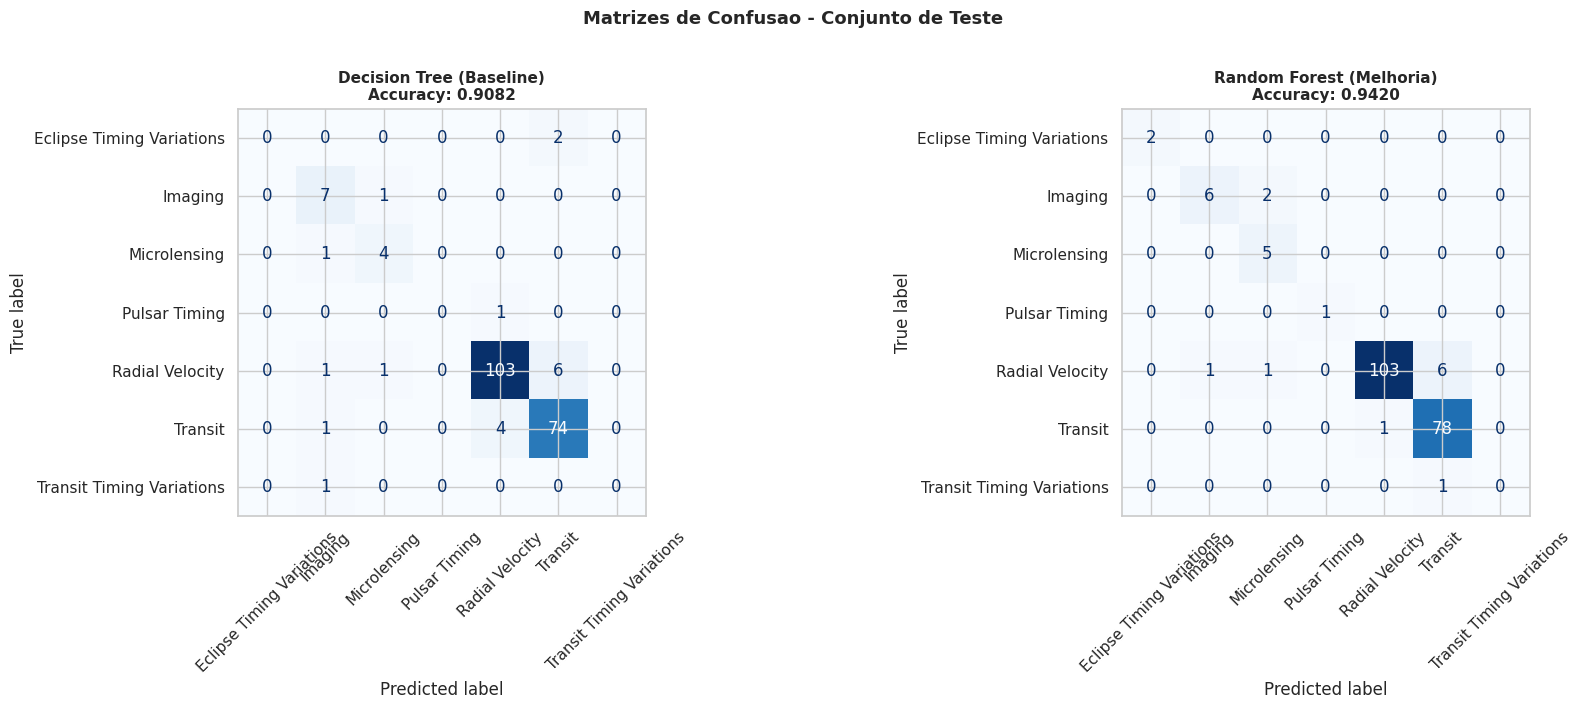

In [11]:
# Matrizes de confusão lado a lado
labels = sorted(y_test.unique())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, y_pred, titulo, acc in zip(
    axes,
    [pred_baseline_dt, pred_improved_rf],
    ["Decision Tree (Baseline)", "Random Forest (Melhoria)"],
    [acc_baseline_dt, acc_improved_rf]
):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
    ax.set_title(f"{titulo}\nAccuracy: {acc:.4f}", fontsize=11, fontweight="bold")

plt.suptitle("Matrizes de Confusao - Conjunto de Teste", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Parte 6 - Interpretação humana dos erros

### Contexto do problema

Classificar o método de detecção de um exoplaneta significa, a partir das suas caracteristicas físicas, dizer qual técnica astronômica foi usada para identificá-lo. Os principais métodos no dataset são:

- **Radial Velocity:** detecta a oscilação gravitacional da estrela; tende a identificar planetas massivos
- **Transit:** detecta queda de brilho quando o planeta cruza a estrela; órbitas curtas
- **Imaging:** fotografia direta; planetas grandes e distantes da estrela
- **Microlensing, Pulsar Timing, etc.:** métodos raros com poucos exemplos

### O que os erros significam neste contexto

Como o problema e multiclasse, FP e FN se aplicam por classe (cada método é o "positivo" contra todos os outros):

- **FN (Transit):** um planeta realmente detectado por Transit foi classificado como outro método. O modelo nao reconheceu a assinatura tipica do Transit (órbita curta, período orbital pequeno).
- **FP (Transit):** o modelo disse que o planeta foi detectado por Transit, mas foi por outro método. Comum porque Transit é a segunda classe mais frequente.
- **FN/FP em classes raras (Astrometry, Orbital Brightness Modulation):** classes com 2-3 exemplos no total dificilmente são aprendidas. O recall tende a ser zero independente do modelo. Isso é uma limitação do dataset, e não do pipeline.

### Qual erro é mais grave?

No contexto científico do dataset, a classificação é retrospectiva (não há decisão de risco direto). O erro mais impactante do ponto de vista do modelo é **confundir Radial Velocity com Transit** (ou vice-versa), pois são as duas classes dominantes. Errar esse ponto significa que o modelo não aprendeu o padrão central dos dados.

### Comparação entre os modelos

**Decision Tree (Baseline):** tende a fazer o overfit no treino, e no teste apresenta maior dispersão fora da diagonal da matriz de confusão. O erro mais comum é a confusão entre as duas classes maioritárias.

**Random Forest (Melhoria):** ao combinar 100 árvores, reduz variância e concentra mais acertos na diagonal. O ganho de accuracy e de F1-weighted é esperado. O F1-macro pode continuar baixo pela presença de classes raras com recall zero, o que não é falha do pipeline mas sim do desbalanceamento do dataset.

## Critério de Excelência - Limitacões e sugestões de melhoria

**Limitacoes identificadas:**

- **Desbalanceamento extremo:** `Radial Velocity` e `Transit` somam mais de 90% dos dados. Classes com menos de 5 exemplos (ex.: `Astrometry`) sao inviséveis para qualquer modelo supervisionado.
- **Missing alto em `mass` (~35-53%):** a imputação por mediana é uma aproximação grosseira. A massa é justamente o que distingue Radial Velocity (planetas massivos) de Transit. Imputar pela mediana pode diluir esse sinal discriminativo.
- **Tamanho relativo ao numero de classes:** ~1035 linhas para 9 classes é insuficiente quando as classes minoritárias tem menos de 10 exemplos.

**Sugestoes de melhoria:**

- **Consolidar classes raras em `Other`:** agrupar métodos com menos de 20 exemplos reduz o problema para 5 classes mais equilibradas e treináveis.
- **`class_weight="balanced"` no RandomForest:** penaliza erros nas classes minoritárias proporcionalmente a sua raridade, forçando o modelo a aprender mesmo com poucos exemplos.
- **KNNImputer em vez de mediana:** usa os vizinhos mais próximos para estimar `mass` e `distance`, preservando melhor a relação entre as features.
- **Feature engineering:** `log1p(orbital_period)` e `log1p(mass)` - essas variáveis tem distribuições extremamente assimétricas (períodos de 0,8 a 320.000 dias). Transformações logarítmicas melhoram a separabilidade entre classes.

In [12]:
import joblib

# Salva o modelo para que seja utilizado em outro local
joblib.dump(model_improved_rf, "pipeline_planets.joblib")
print("Modelo salvo.")

Modelo salvo.


In [13]:
# Utilizando o modelo em um novo local

# Exemplo de um novo dataframe com outros dados
# Em um cenário real, terá uma carga maior de dados, e não será apenas 2 linhas.
df_new = pd.DataFrame([
    {"number": 1, "orbital_period": 4.2,   "mass": np.nan, "distance": 500.0, "year": 2012},
    {"number": 2, "orbital_period": 1200.0, "mass": 3.5,   "distance": np.nan, "year": 2008},
])

model = joblib.load("pipeline_planets.joblib")
pred = model.predict(df_new)
print(pred)

['Transit' 'Radial Velocity']
